# Exercise 2

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In this exercise, you may use built-in procedures for generating random numbers.
Compare the results obtained from simulation with the corresponding theoretical results.
Use histograms and statistical tests where appropriate

## Part 1

Choose a value for the probability parameter (p) in the geometric distribution and
simulate 10,000 observations.

Compare the simulated and theoretical distributions. You should experiment with
small, moderate, and large values of p

In [2]:
#sample size
n_samples = 10000

#probability parameters for geom dist.: large, moderate, small
p_large = 0.75
p_moderate = 0.5
p_small = 1/100

In [3]:
### Construct own function for sampling from geom dist. using uniform dist 
# (slide: Day2, Sampling from discrete distributions, slide 12)
# using numpy's RNG
def sample_geometric(p, n):
    # Set seed
    np.random.seed(42)
    #Draw uniform distribution (using numpy)
    U = np.random.uniform(size=n)
    #Map to geometric dist with given p-param
    geom = np.floor(np.log(U)/np.log(1-p)) + 1 
    return geom.astype(int)

In [4]:
### Compute from own sampling function
obs_geom_s = sample_geometric(p=p_small, n=n_samples)
obs_geom_m = sample_geometric(p=p_moderate, n=n_samples)
obs_geom_l = sample_geometric(p=p_large, n=n_samples)

print("max of obs_geom_small: ", np.max(obs_geom_s))
print("max of obs_geom_moderate: ", np.max(obs_geom_m))
print("max of obs_geom_large: ", np.max(obs_geom_l))

max of obs_geom_small:  1131
max of obs_geom_moderate:  17
max of obs_geom_large:  9


In [5]:
### Bin edges for plotting
edges_l = np.linspace(0.5, np.max(obs_geom_l)+ 0.5, num=np.max(obs_geom_l)+1)
edges_m = np.linspace(0.5, np.max(obs_geom_m)+ 0.5, num=np.max(obs_geom_m)+1)
edges_s = np.linspace(0.5, np.max(obs_geom_s)+ 0.5, num=np.max(obs_geom_s)+1)

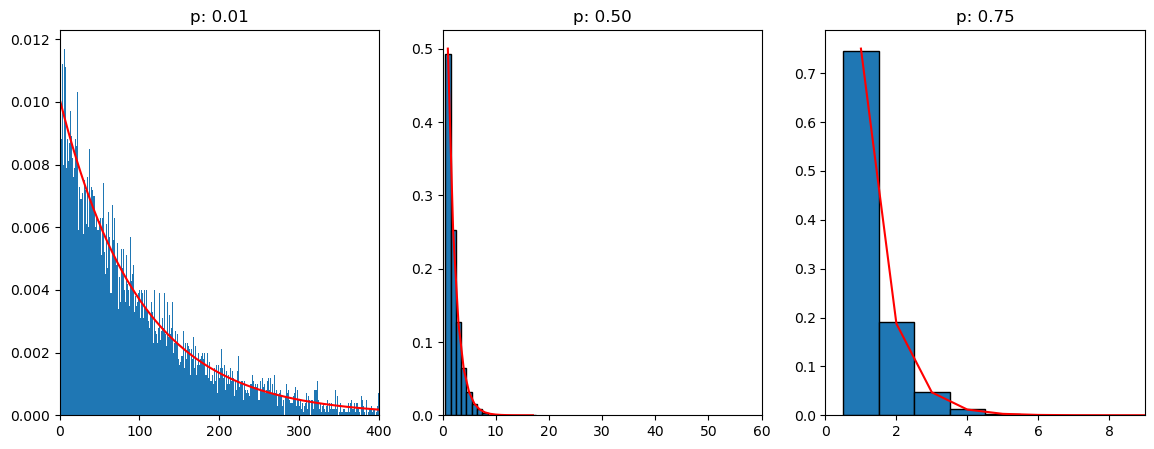

In [6]:
# PLot distributions and their pdf

xgrid_s = np.arange(1,np.max(obs_geom_s)+1)
xgrid_m = np.arange(1,np.max(obs_geom_m)+1)
xgrid_l = np.arange(1,np.max(obs_geom_l)+1)

### Plotting - plotting density (count normalised by total count AND bind width, which is here 1)
fig, axs = plt.subplots(1,3, figsize=(14,5))

axs[0].hist(obs_geom_s, bins=edges_s, density=True)
axs[0].set_title(f"p: {p_small:.2f}")
axs[0].set_xlim(0,400)
#plot pfd
axs[0].plot(xgrid_s, sp.stats.geom.pmf(k=xgrid_s, p=p_small), color='red')

axs[1].hist(obs_geom_m, bins=edges_m, edgecolor='black', density=True)
axs[1].set_title(f"p: {p_moderate:.2f}")
axs[1].plot(xgrid_m, sp.stats.geom.pmf(k=xgrid_m, p=p_moderate), color='red')
axs[1].set_xlim(0,60)

axs[2].hist(obs_geom_l, bins=edges_l, edgecolor='black', density=True)
axs[2].set_title(f"p: {p_large:.2f}")
axs[2].plot(xgrid_l, sp.stats.geom.pmf(k=xgrid_l, p=p_large), color='red')
axs[2].set_xlim(0,9)
#axs[2].set_ylim(0,0.01)

plt.show()

In [7]:
### Check validity using chi-squared:

#classes: max obs.
n_class_s = np.max(obs_geom_s)
n_class_m = np.max(obs_geom_m)
n_class_l = np.max(obs_geom_l)

#creating f_obs: observed frequency (meaning simple count) in each category
f_obs_l = np.histogram(obs_geom_l, bins=n_class_l)[0]
f_obs_m = np.histogram(obs_geom_m, bins=n_class_m)[0]
f_obs_s = np.histogram(obs_geom_s, bins=n_class_s)[0]

#checking
print('f_obs_l:')
print(f_obs_l)

print('sums of f_obs (should be n_RNs)')
print(sum(f_obs_l))
print(sum(f_obs_m))
print(sum(f_obs_s))

### Creating f_exp: expected freq. in each cat. (meaning count)
# NB: last category must encompass all obs over max obs to include tail of prob dist.
# --> add 'probability tail' to this cat

#Compute probabilities
f_exp_l = sp.stats.geom.pmf(np.linspace(1,n_class_l, n_class_l), p_large)
#Append 'tail probability' by integral of pdf from max obs to inf
f_exp_l[-1] += (1-np.sum(f_exp_l))
#Convert to counts
f_exp_l *= n_samples

f_exp_m = sp.stats.geom.pmf(np.linspace(1,n_class_m, n_class_m), p_moderate) 
f_exp_m[-1] += + (1-np.sum(f_exp_m))
f_exp_m *= n_samples

f_exp_s = sp.stats.geom.pmf(np.linspace(1,n_class_s, n_class_s), p_small)
f_exp_s[-1] += (1-np.sum(f_exp_s))
f_exp_s *= n_samples

#checking
print('sums of f_exp (should be n_RNs)')
print(sum(f_exp_l))
print(sum(f_exp_m))
print(sum(f_exp_s))

# Computing chi-square test statistics and p-values
# NB: we have estimated no parameters of the expected distribution (the uniform dist.) - they  were given

Tstat_l, pval_l = sp.stats.chisquare(f_obs_l, f_exp=f_exp_l, ddof=0)
Tstat_m, pval_m = sp.stats.chisquare(f_obs_m, f_exp=f_exp_m, ddof=0)
Tstat_s, pval_s = sp.stats.chisquare(f_obs_s, f_exp=f_exp_s, ddof=0)

print("results:")
print(f"Tstat_l: {Tstat_l:.2e}")
print(f"pval_l: {pval_l:.2e}")
print(f"Tstat_m: {Tstat_m:.2e}")
print(f"pval_m: {pval_m:.2e}")
print(f"Tstat_s: {Tstat_s:.2e}")
print(f"pval_s: {pval_s:.2e}")

f_obs_l:
[7453 1915  478  122   16    8    5    2    1]
sums of f_obs (should be n_RNs)
10000
10000
10000
sums of f_exp (should be n_RNs)
10000.0
10000.0
10000.000000000015
results:
Tstat_l: 2.30e+01
pval_l: 3.35e-03
Tstat_m: 3.79e+01
pval_m: 1.58e-03
Tstat_s: 1.76e+03
pval_s: 3.01e-30


## Part 2

Consider the six-point distribution ....
Generate observations from this distribution using methods below

In [8]:
### Given Six point distribution
# outcomes
x_i = np.array([1, 2, 3, 4, 5, 6])

# probabilities
p_i = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])

# Cumulative distribution function
F_i = np.cumsum(p_i)

#Checking
print("sum of probabilites: ", np.sum(p_i))
print("cumulative distribution function:")
print(F_i)

#sample size (used later)
n_samples = 10000

sum of probabilites:  1.0
cumulative distribution function:
[0.14583333 0.25       0.375      0.4375     0.6875     1.        ]


### Crude method

In [9]:
def sixpoint_crude(n, x_i, p_i):
    """
    input:
        n [int]:          sample size
        p_i [list]:         probabilities
        x_i [list]:       outcomes
    returns:
        samples [length n]
    """
    # Set seed
    np.random.seed(42)
    #Draw uniform distribution (using numpy)
    U = np.random.uniform(size=n)

    #C Compute  cumulative sum
    F_i = np.cumsum(p_i)

    # initialise samples
    X = np.zeros(n)

    for i in range(n):
        for j in range(len(p_i)):
            # Check if F(x_{i-1}) < U <= F(x_i)
            if U[i] <= F_i[j]:
                X[i] = x_i[j]
                break

    return np.array(X)

In [10]:
### Draw from dist using crude method

X_crude = sixpoint_crude(n=n_samples, x_i=x_i, p_i=p_i)


[0.5 1.5 2.5]


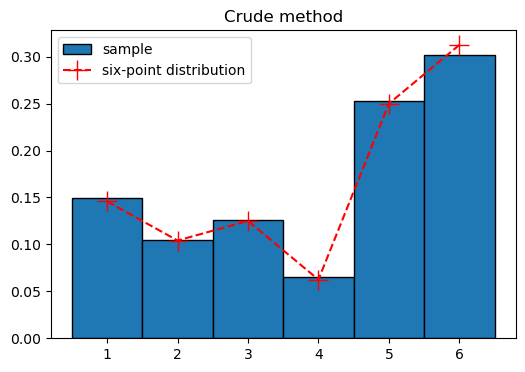

In [11]:
### Plotting - plotting density (count normalised by total count AND bind width, which is here 1)

# Edges for bins
edges = np.linspace(start=0.5, stop=np.max(X_crude) + 0.5, num=int(np.max(X_crude))+1)
print(edges[:3])

#Create figure
fig, axs = plt.subplots(1,1, figsize=(6,4))

axs.hist(X_crude, bins=edges, edgecolor='black', density=True, label='sample')
axs.plot(np.linspace(1,6,6), p_i, label='six-point distribution', color='red', marker='+', markersize=15, linestyle='--')
axs.legend()
axs.set_title("Crude method")

plt.show()

In [12]:
### Goodness of fit ....
## Using KS

### Rejection method

In [13]:
def sixpoint_rejection_simple(n, p_i, x_i):
    """
    input:
        n (int):          sample size
        p_i (list):       probabilities
        x_i (list):       outcomes
    returns:
        X (list):         Samples (length n)     
        i (int):          iteration counter  
    """
    #Number of observations
    k = len(p_i)
    # Compute c
    c = np.max(p_i)
    # Set seed for RNG
    np.random.seed(42)

    # Initialise sample list
    X = []

    #iteration variable
    i=0
    while len(X) < n:
        #Draw uniform distribution (using numpy)
        U1 = np.random.uniform()

        # Step 1: Choose proposal (generate I), using 0-index
        I_idx = int(np.floor(k*U1))
        I = x_i[I_idx]
        p_I = p_i[I_idx]

        # Step 2: Try proposal
        U2 = np.random.uniform()
        if U2 <= (p_I/c):
            X.append(I)

        # Increase iteration counter
        i += 1
        #Safe break
        if i > n*1000:
            break

    return np.array(X), i

In [14]:
### Draw from dist. using rejection method

X_reject, i_reject = sixpoint_rejection_simple(n=n_samples, x_i=x_i, p_i=p_i)

print("iterations used: ", i_reject)

iterations used:  18858


[0.5 1.5 2.5]


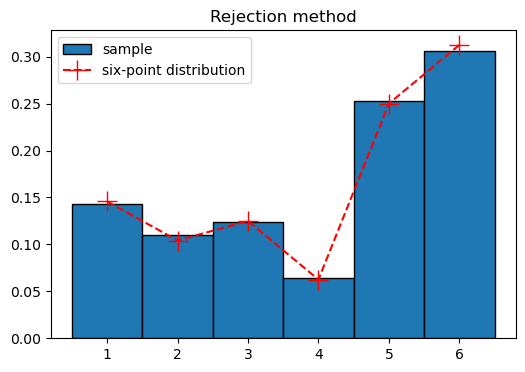

In [15]:
### Plotting rejection - plotting density (count normalised by total count AND bind width, which is here 1)

# Edges for bins
edges = np.linspace(start=0.5, stop=np.max(X_reject) + 0.5, num=int(np.max(X_reject))+1)
print(edges[:3])

#Create figure
fig, axs = plt.subplots(1,1, figsize=(6,4))

axs.hist(X_reject, bins=edges, edgecolor='black', density=True, label='sample')
axs.plot(np.linspace(1,6,6), p_i, label='six-point distribution', color='red', marker='+', markersize=15, linestyle='--')
axs.legend()
axs.set_title("Rejection method")

plt.show()

### Alias method

In [16]:
### Generate alias tables
# (from slides: Generation of random variables-Discrete sample space, Bo Friis Nielsen, slide 16)
def alias_generate_table(p_i):
    """
    input:
        p_i (list):     list of discrete probabilities
    output:
        F (array):      list of F(I) values 
                        (which part of of the prob. mass belongs to I itself)
        L (array):      list of L(I) values (the alias of class I)
    """
    # number of outcomes
    k = len(p_i)
    print("p: ", p_i)
    print("p*k: ", p_i*k)

    # 1) Initialise L (loaners)
    L = np.linspace(1,6,6)

    # 2) Initialise F (fortune/formue)
    F = k*p_i

    print("F (before aliasing): ",F)
    print("L (before aliasing): ",L)

    # 3) Make masks for G (givers) and S (spongers/snyltere) 
    # i.e. indices for elements, where condition is true
    G = [i for i, f in enumerate(F) if f > 1.0]
    S = [i for i, f in enumerate(F) if f < 1.0]
    print("G (idx for givers): ", G)
    print("S (idx for spongers): ", S)

    #small number for comp.
    eps = 1e-12

    # 4) Assign S outcomes to L outcomes 
    # (determine L and F tables)
    while len(S) != 0:
        # a)
        i = G[0]    #extract one giver index
        j = S[0]    #extract one sponger index
        # b)
        L[j] = i+1             #Make sponger j loan from giver i (update L) (NB: 0-index -> outcome by +1)
        F[i] -= (1-F[j])      #reduce fortune of giver i by amount that loaner j needs to get to 1
        # c)
        if F[i] < (1-eps):  #if fortune of giver i has become less than 1
            G.pop(0)        #remove giver i from giver list
            S.append(i)     #add giver i to sponger list
        # d)
        S.pop(0)    #remove sponger j from list (it now has fortune 1)

    # Convert from 0-index 
    return np.array(F), np.array(L)

In [17]:
### Construct Alias method
def sixpoint_alias(n, p_i, x_i, F, L):
    """
    input:
        n (int):          sample size
        p_i (list):       probabilities
        x_i (list):       outcomes
        F (array):        list of F(I) values 
                          which part of of the prob. mass belongs to I itself)
        L (array):        list of L(I) values (the alias of class I)
    returns:
        X (list):         Samples (length n)     
        i (int):          iteration counter      
    """

    #Number of observations
    k = len(p_i)
    # Set seed for RNG
    np.random.seed(42)
    # Initialise sample list
    X = []

    #iteration variable
    i=0

    while len(X) < n:
        
        # 1) generate I
        # Draw uniform distribution (using numpy)
        U1 = np.random.uniform()
        # generate I from x_i
        I_idx = int(np.floor(k*U1))
        I = x_i[I_idx]
        
        # 2) test against F(I)
        # Draw uniform distribution (using numpy)
        U2 = np.random.uniform()
        # if U2 <= F(I):  return I itself 
        if U2 <= F[I_idx]:
            X.append(I)
        # else: return alias, L(I)
        else:
            X.append(L[I_idx])

        # Increase iteration counter
        i += 1
        #Safe break
        if i > n*10:
            break
    return np.array(X), i

In [18]:
### Apply method

#p_i = np.array([17/96, 1/12, 1/3, 1/4, 1/24, 11/96])

F, L = alias_generate_table(p_i=p_i)
print("results:")
print("F: ",F)
print("L: ",L)

X_alias, i = sixpoint_alias(n=n_samples, x_i=x_i, p_i=p_i, F=F, L=L)
print("iterations used: ", i)

p:  [0.14583333 0.10416667 0.125      0.0625     0.25       0.3125    ]
p*k:  [0.875 0.625 0.75  0.375 1.5   1.875]
F (before aliasing):  [0.875 0.625 0.75  0.375 1.5   1.875]
L (before aliasing):  [1. 2. 3. 4. 5. 6.]
G (idx for givers):  [4, 5]
S (idx for spongers):  [0, 1, 2, 3]
results:
F:  [0.875 0.625 0.75  0.375 0.75  1.   ]
L:  [5. 5. 5. 6. 6. 6.]
iterations used:  10000


[0.5 1.5 2.5]


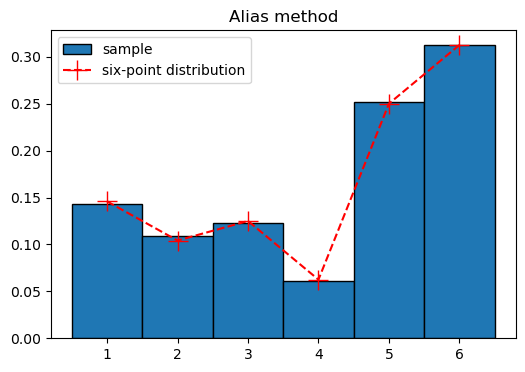

In [19]:
### Plotting alias - plotting density (count normalised by total count AND bind width, which is here 1)

# Edges for bins
edges = np.linspace(start=0.5, stop=np.max(X_alias) + 0.5, num=int(np.max(X_alias))+1)
print(edges[:3])

#Create figure
fig, axs = plt.subplots(1,1, figsize=(6,4))

axs.hist(X_alias, bins=edges, edgecolor='black', density=True, label='sample')
axs.plot(np.linspace(1,6,6), p_i, label='six-point distribution', color='red', marker='+', markersize=15, linestyle='--')
axs.legend()
axs.set_title("Alias method")

plt.show()

## Part 3

Compare the three generation methods using appropriate performance measures and discuss the results.
Possible criteria include:
- Computational efficiency
- Ease of implementation
- Memory requirements
- Accuracy of the generated distribution

In [20]:
### To wit:
# outcomes
x_i = np.array([1, 2, 3, 4, 5, 6])
# probabilities
p_i = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])
#sample size (used later)
n_samples = 10000
# number of outcomes
k = np.size(p_i)

In [21]:
### Chi squared test 

## Creating f_exp: expected freq. in each cat. (count)
f_exp = p_i*n_samples
# checking
print('sum of f_exp (should be n_samples)')
print(sum(f_exp))

## Creating f_obs: observed frequency (count) in each category
f_obs_crude = np.histogram(X_crude, bins=k)[0]
f_obs_reject = np.histogram(X_reject, bins=k)[0]
f_obs_alias = np.histogram(X_alias, bins=k)[0]
#Checking
print('sums of f_obs (should be n_samples)')
print(sum(f_obs_crude))
print(sum(f_obs_reject))
print(sum(f_obs_alias))

# Computing chi-square test statistics and p-values
# NB: we have estimated no parameters of the expected distribution (the six-point dist) --> ddof = 0
Tstat_crude, pval_crude = sp.stats.chisquare(f_obs_crude, f_exp=f_exp, ddof=0)
Tstat_reject, pval_reject = sp.stats.chisquare(f_obs_reject, f_exp=f_exp, ddof=0)
Tstat_alias, pval_alias = sp.stats.chisquare(f_obs_alias, f_exp=f_exp, ddof=0)

print("results:")
print(f"Tstat_crude: {Tstat_crude:.2g}")
print(f"pval_crude: {pval_crude:.2g}")
print(f"Tstat_reject: {Tstat_reject:.2g}")
print(f"pval_reject: {pval_reject:.2g}")
print(f"Tstat_alias: {Tstat_alias:.2g}")
print(f"pval_alias: {pval_alias:.2g}")

sum of f_exp (should be n_samples)
10000.0
sums of f_obs (should be n_samples)
10000
10000
10000
results:
Tstat_crude: 5.8
pval_crude: 0.33
Tstat_reject: 6
pval_reject: 0.31
Tstat_alias: 3.5
pval_alias: 0.63


In [ ]:
#Iterations of setting c in different ways:
#c = np.max(p_i) *1.01:    pval_reject: 0.27
#c = np.max(p_i):           pval_reject: 0.31
#c = np.max(p_i) * 2:      pval_reject: 0.056